In [1]:
import pandas as pd
import numpy as np
import os

# Define the base path to the raw data
raw_dir = 'dataset/ogbn_arxiv/raw'
mapping_dir = 'dataset/ogbn_arxiv/mapping'

# 1. Load the Citation Edges (adjacency list)
# Format: source_node, target_node
edges = pd.read_csv(os.path.join(raw_dir, 'edge.csv.gz'), compression='gzip', header=None)
edges.columns = ['source', 'target']

# 2. Load the Node Features (128-dimensional embeddings)
# These are usually stored as a compressed CSV or NPY. OGB uses CSV.gz for raw.
node_feat = pd.read_csv(os.path.join(raw_dir, 'node-feat.csv.gz'), compression='gzip', header=None)

# 3. Load Node years
node_year = pd.read_csv(os.path.join(raw_dir, 'node_year.csv.gz'), compression='gzip', header=None)
node_year.columns = ['year']

# 4. Load Node to Paper ID mapping (Critical for linking to titleabs.tsv)
node_mapping = pd.read_csv(os.path.join(mapping_dir, 'nodeidx2paperid.csv.gz'), compression='gzip')

# 5. Load labels (subject categories)
labels = pd.read_csv(os.path.join(raw_dir, 'node-label.csv.gz'), compression='gzip', header=None)

print(f"Loaded {len(node_feat)} nodes")
print(f"Loaded {len(edges)} citation links")
print(f"Columns in mapping: {node_mapping.columns.tolist()}")

Loaded 169343 nodes
Loaded 1166243 citation links
Columns in mapping: ['node idx', 'paper id']


In [2]:
# load mapping from label numbers to category names
label_category_mapping = pd.read_csv(os.path.join(mapping_dir, 'labelidx2arxivcategeory.csv.gz'), compression='gzip')

# Display the unique categories
print(label_category_mapping.head())
print(f"Total categories: {len(label_category_mapping)}")

   label idx arxiv category
0          0    arxiv cs na
1          1    arxiv cs mm
2          2    arxiv cs lo
3          3    arxiv cs cy
4          4    arxiv cs cr
Total categories: 40


In [3]:
print(node_year)

        year
0       2013
1       2015
2       2014
3       2014
4       2014
...      ...
169338  2020
169339  2020
169340  2020
169341  2020
169342  2020

[169343 rows x 1 columns]


We see that (u, v) is an edge if u cites v

In [23]:
# Map source and target node indices to their publication years
source_years = node_year.loc[edges['source'], 'year'].values
target_years = node_year.loc[edges['target'], 'year'].values

# Calculate the fraction of edges matching each direction
source_cites_target = (source_years >= target_years).mean()
target_cites_source = (target_years >= source_years).mean()

print(f"Fraction of edges where source_year >= target_year (u cites v): {source_cites_target:.4%}")
print(f"Fraction of edges where target_year >= source_year (v cites u): {target_cites_source:.4%}")


Fraction of edges where source_year >= target_year (u cites v): 98.2077%
Fraction of edges where target_year >= source_year (v cites u): 12.8549%


We include only papers from years 2000-2012

In [4]:
target_years = [year for year in range(2000, 2013)]
papers_in_range = node_year[node_year['year'].isin(target_years)]
print(papers_in_range.head(10))
node_indices = set(papers_in_range.index.tolist())

    year
7   2011
10  2012
13  2004
18  2009
21  2010
22  2008
26  2009
29  2011
33  2012
40  2008


In [7]:
import networkx as nx

nodes = list(node_indices)
G = nx.DiGraph()

G.add_nodes_from(nodes)

# Convert each edge to a tuple of (int, int)
edges_to_add = [tuple(map(int, edge)) for edge in filtered_edges.values]
G.add_edges_from(edges_to_add)


In [8]:
# Create a set for fast O(1) lookup
edge_set = set(edges_to_add)

# Find edges (u, v) where (v, u) also exists in the list
reciprocal_edges = [edge for edge in edges_to_add if (edge[1], edge[0]) in edge_set]

print(f"Total edges: {len(edges_to_add)}")
print(f"Number of reciprocal edges found: {len(reciprocal_edges)}")

if reciprocal_edges:
    print("Example reciprocal edges (source, target):")
    for i in range(min(5, len(reciprocal_edges))):
        u, v = reciprocal_edges[i]
        print(f"Edge: ({u}, {v}) | Opposite: ({v}, {u})")

Total edges: 45697
Number of reciprocal edges found: 3156
Example reciprocal edges (source, target):
Edge: (148333, 7857) | Opposite: (7857, 148333)
Edge: (83333, 10551) | Opposite: (10551, 83333)
Edge: (76903, 9122) | Opposite: (9122, 76903)
Edge: (148337, 142396) | Opposite: (142396, 148337)
Edge: (25140, 29192) | Opposite: (29192, 25140)


There are many reciprocal edges, for example:
Year 2012 <-> Year 2003


In [9]:
# Check years of reciprocal edges
for i in range(min(10, len(reciprocal_edges))):
    u, v = reciprocal_edges[i]
    year_u = node_year.loc[u, 'year']
    year_v = node_year.loc[v, 'year']
    print(f"Edge ({u}, {v}): Year {year_u} <-> Year {year_v}")

Edge (148333, 7857): Year 2012 <-> Year 2003
Edge (83333, 10551): Year 2009 <-> Year 2009
Edge (76903, 9122): Year 2006 <-> Year 2007
Edge (148337, 142396): Year 2011 <-> Year 2009
Edge (25140, 29192): Year 2010 <-> Year 2011
Edge (15861, 99171): Year 2011 <-> Year 2010
Edge (152174, 123132): Year 2008 <-> Year 2008
Edge (96623, 137697): Year 2003 <-> Year 2003
Edge (115174, 2706): Year 2007 <-> Year 2007
Edge (115174, 135871): Year 2007 <-> Year 2007


Removing single nodes in weakly connected components (they are useless):

In [11]:
nodes_for_removal = []
for comp in nx.weakly_connected_components(G):
        if len(comp) == 1:
            for node in comp:
                nodes_for_removal.append(node)

G.remove_nodes_from(nodes_for_removal)

## Random Networks Generation and Comparison

First we describe our network with relevant general information


In [24]:
from network_utils import describe_network_directed, describe_network_undirected
describe_network_directed(G)

,Nodes,Edges,Average In/Out Degree,Weakly Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,45697,2.227492,965,0.135714,16874,10.120089


We generate three random networks:
- Watts-Strogatz
- Erdos-Renyi
- Barabasi-Albert

In [14]:
G_undir = G.to_undirected()
v = G_undir.number_of_nodes()
e = G_undir.number_of_edges()
erdos = nx.gnm_random_graph(v, e)
barabasi = nx.barabasi_albert_graph(v, round(e/v))
watts = nx.connected_watts_strogatz_graph(v, round(2*e/v), 0.1)


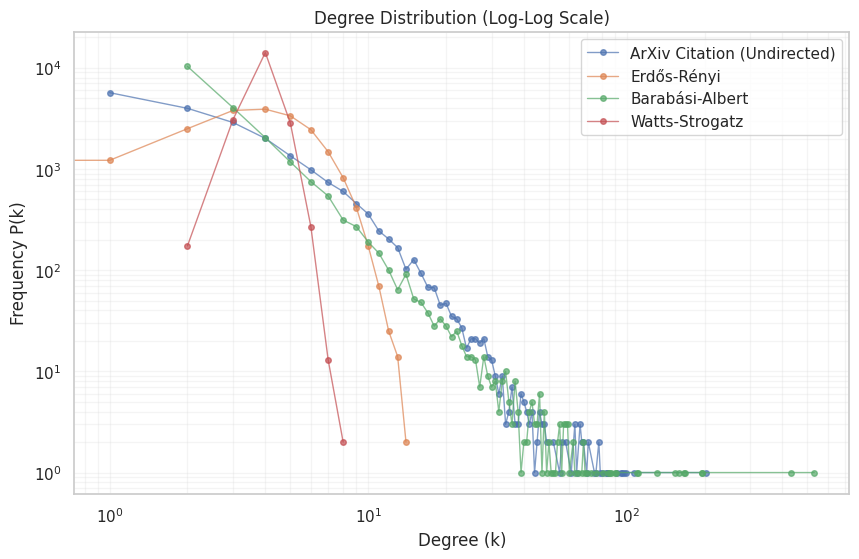

In [25]:
from network_utils import plot_degree_distribution
# List of graphs and their labels
graphs = [G_undir, erdos, barabasi, watts]
labels = ["ArXiv Citation (Undirected)", "Erdős-Rényi", "Barabási-Albert", "Watts-Strogatz"]

plot_degree_distribution(graphs, labels)

We see that ArXiv Citations network follows Barabasi-Albert Degree Distribution so it means that the Network is scale-free.

In [16]:
df_watts = describe_network_undirected(watts)

In [17]:
df_barabasi = describe_network_undirected(barabasi)

In [18]:
df_erdos = describe_network_undirected(erdos)

In [19]:
df_citations = describe_network_undirected(G_undir)

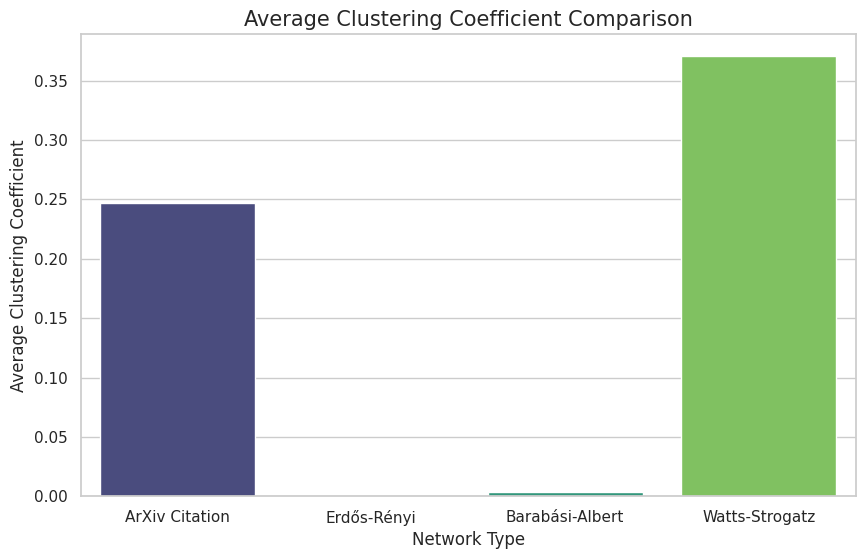

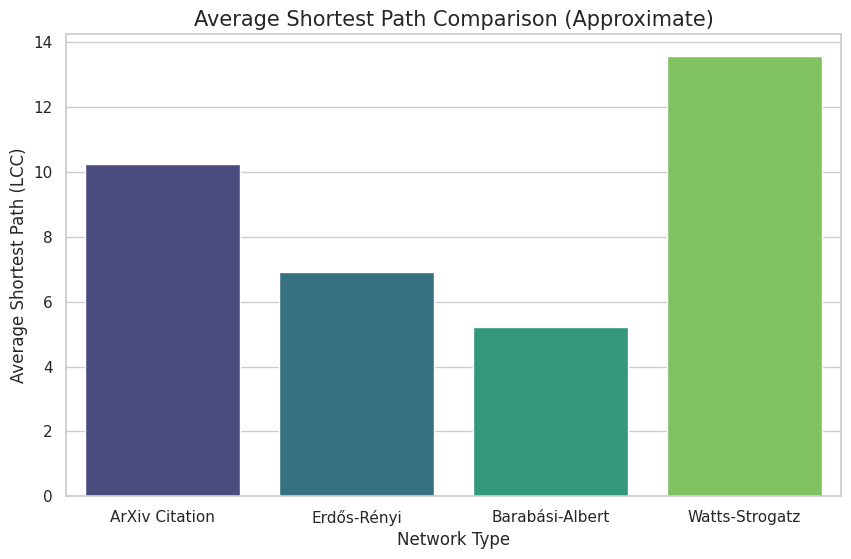

In [20]:
results = pd.concat([df_citations, df_erdos, df_barabasi, df_watts], ignore_index=True)
results['Network'] = ["ArXiv Citation", "Erdős-Rényi", "Barabási-Albert", "Watts-Strogatz"]

import seaborn as sns
sns.set_theme(style="whitegrid")

# Plot 1: Average Clustering Coefficient
plt.figure(figsize=(10, 6))
sns.barplot(data=results, x='Network', y='Average Clustering Coefficient', hue='Network', palette='viridis', legend=False)
plt.title('Average Clustering Coefficient Comparison', fontsize=15)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.xlabel('Network Type', fontsize=12)
plt.show()

# Plot 2: Average Shortest Path
plt.figure(figsize=(10, 6))
sns.barplot(data=results, x='Network', y='Average Shortest Path', hue='Network', palette='viridis', legend=False)
plt.title('Average Shortest Path Comparison (Approximate)', fontsize=15)
plt.ylabel('Average Shortest Path (LCC)', fontsize=12)
plt.xlabel('Network Type', fontsize=12)
plt.show()

In [21]:
results

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path,Network
0,20515,44119,4.301146,965,0.247071,16874,10.234875,ArXiv Citation
1,20515,44119,4.301146,326,0.000130,20186,6.915557,Erdős-Rényi
2,20515,41026,3.999610,1,0.003169,20515,5.228506,Barabási-Albert
3,20515,41030,4.000000,1,0.370568,20515,13.570094,Watts-Strogatz
